In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
import numpy as np

In [2]:
materials = pd.read_csv("C:\\Users\\sneha\\Desktop\\AI-Powered-Sustainable-Packaging-Recommendation-System\\data\\raw\\material_dataset.csv")
products = pd.read_csv("C:\\Users\\sneha\\Desktop\\AI-Powered-Sustainable-Packaging-Recommendation-System\\data\\raw\\product_dataset.csv")


In [3]:
materials.info()
materials.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Material ID                             404 non-null    object 
 1   Packaging Type                          404 non-null    object 
 2   Material Type                           404 non-null    object 
 3   Suitable Product Categories             404 non-null    object 
 4   Recommended Packaging Use Cases         404 non-null    object 
 5   Supplier Region                         404 non-null    object 
 6   Recyclability (%)                       404 non-null    int64  
 7   Recyclability Category                  404 non-null    object 
 8   Recycled Content (%)                    403 non-null    float64
 9   Reusability (%)                         403 non-null    float64
 10  Biodegradation Time (days)              403 non-null    float6

,Recyclability (%),Recycled Content (%),Reusability (%),Biodegradation Time (days),End-of-Life Disposal (%),Carbon Footprint (kg CO2/unit),CO2 Emission per kg (estimated),Waste Reduction Impact (%),Sustainability Target Progress (%),Load Handling Score,Moisture Resistance Score,Thermal Resistance Score,Cost per Unit (USD),Annual Usage (units),Total Material Weight (tons),Supplier Sustainability Compliance (%)
count,404.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000
mean,91.613861,61.833747,66.694789,31396.910670,9.039702,1.186774,1.148387,68.034739,83.997519,6.498759,6.059553,5.697270,8.935931,67070.555831,1153.957816,87.466501
std,8.584966,19.340228,28.766147,37072.185094,5.561811,0.748728,0.720590,13.839297,9.015878,2.094027,2.470004,1.870873,7.092944,26822.383226,1099.929480,7.283235
min,55.000000,21.000000,3.000000,31.000000,2.000000,0.310000,0.280000,24.000000,54.000000,1.000000,1.000000,2.000000,0.210000,14649.000000,145.000000,63.000000
25%,87.000000,47.500000,48.000000,197.000000,5.000000,0.780000,0.510000,60.000000,82.000000,5.000000,4.000000,4.000000,2.810000,49673.000000,743.000000,85.000000
50%,94.000000,68.000000,53.000000,28329.000000,8.000000,0.990000,1.400000,69.000000,86.000000,7.000000,7.000000,6.000000,3.870000,59942.000000,901.000000,88.000000
75%,99.000000,79.000000,95.000000,50709.500000,11.000000,1.180000,1.500000,79.000000,90.000000,8.000000,8.000000,7.000000,14.650000,96931.500000,1072.000000,92.000000
max,100.000000,94.000000,100.000000,180208.000000,26.000000,3.670000,3.250000,89.000000,100.000000,10.000000,10.000000,10.000000,25.950000,104546.000000,5092.000000,100.000000


In [4]:
products.info()
products.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         1500 non-null   int64  
 1   product_name       1500 non-null   object 
 2   category           1500 non-null   object 
 3   product_weight_kg  1500 non-null   float64
 4   fragility_index    1500 non-null   int64  
 5   shipping_type      1500 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 70.4+ KB


,product_id,product_weight_kg,fragility_index
count,1500.000000,1500.000000,1500.000000
mean,750.500000,0.925087,2.617333
std,433.157015,1.604414,1.087361
min,1.000000,0.040000,1.000000
25%,375.750000,0.300000,2.000000
50%,750.500000,0.520000,3.000000
75%,1125.250000,0.900000,3.000000
max,1500.000000,15.000000,5.000000


In [5]:
materials.isnull().sum()
products.isnull().sum()


product_id           0
product_name         0
category             0
product_weight_kg    0
fragility_index      0
shipping_type        0
dtype: int64

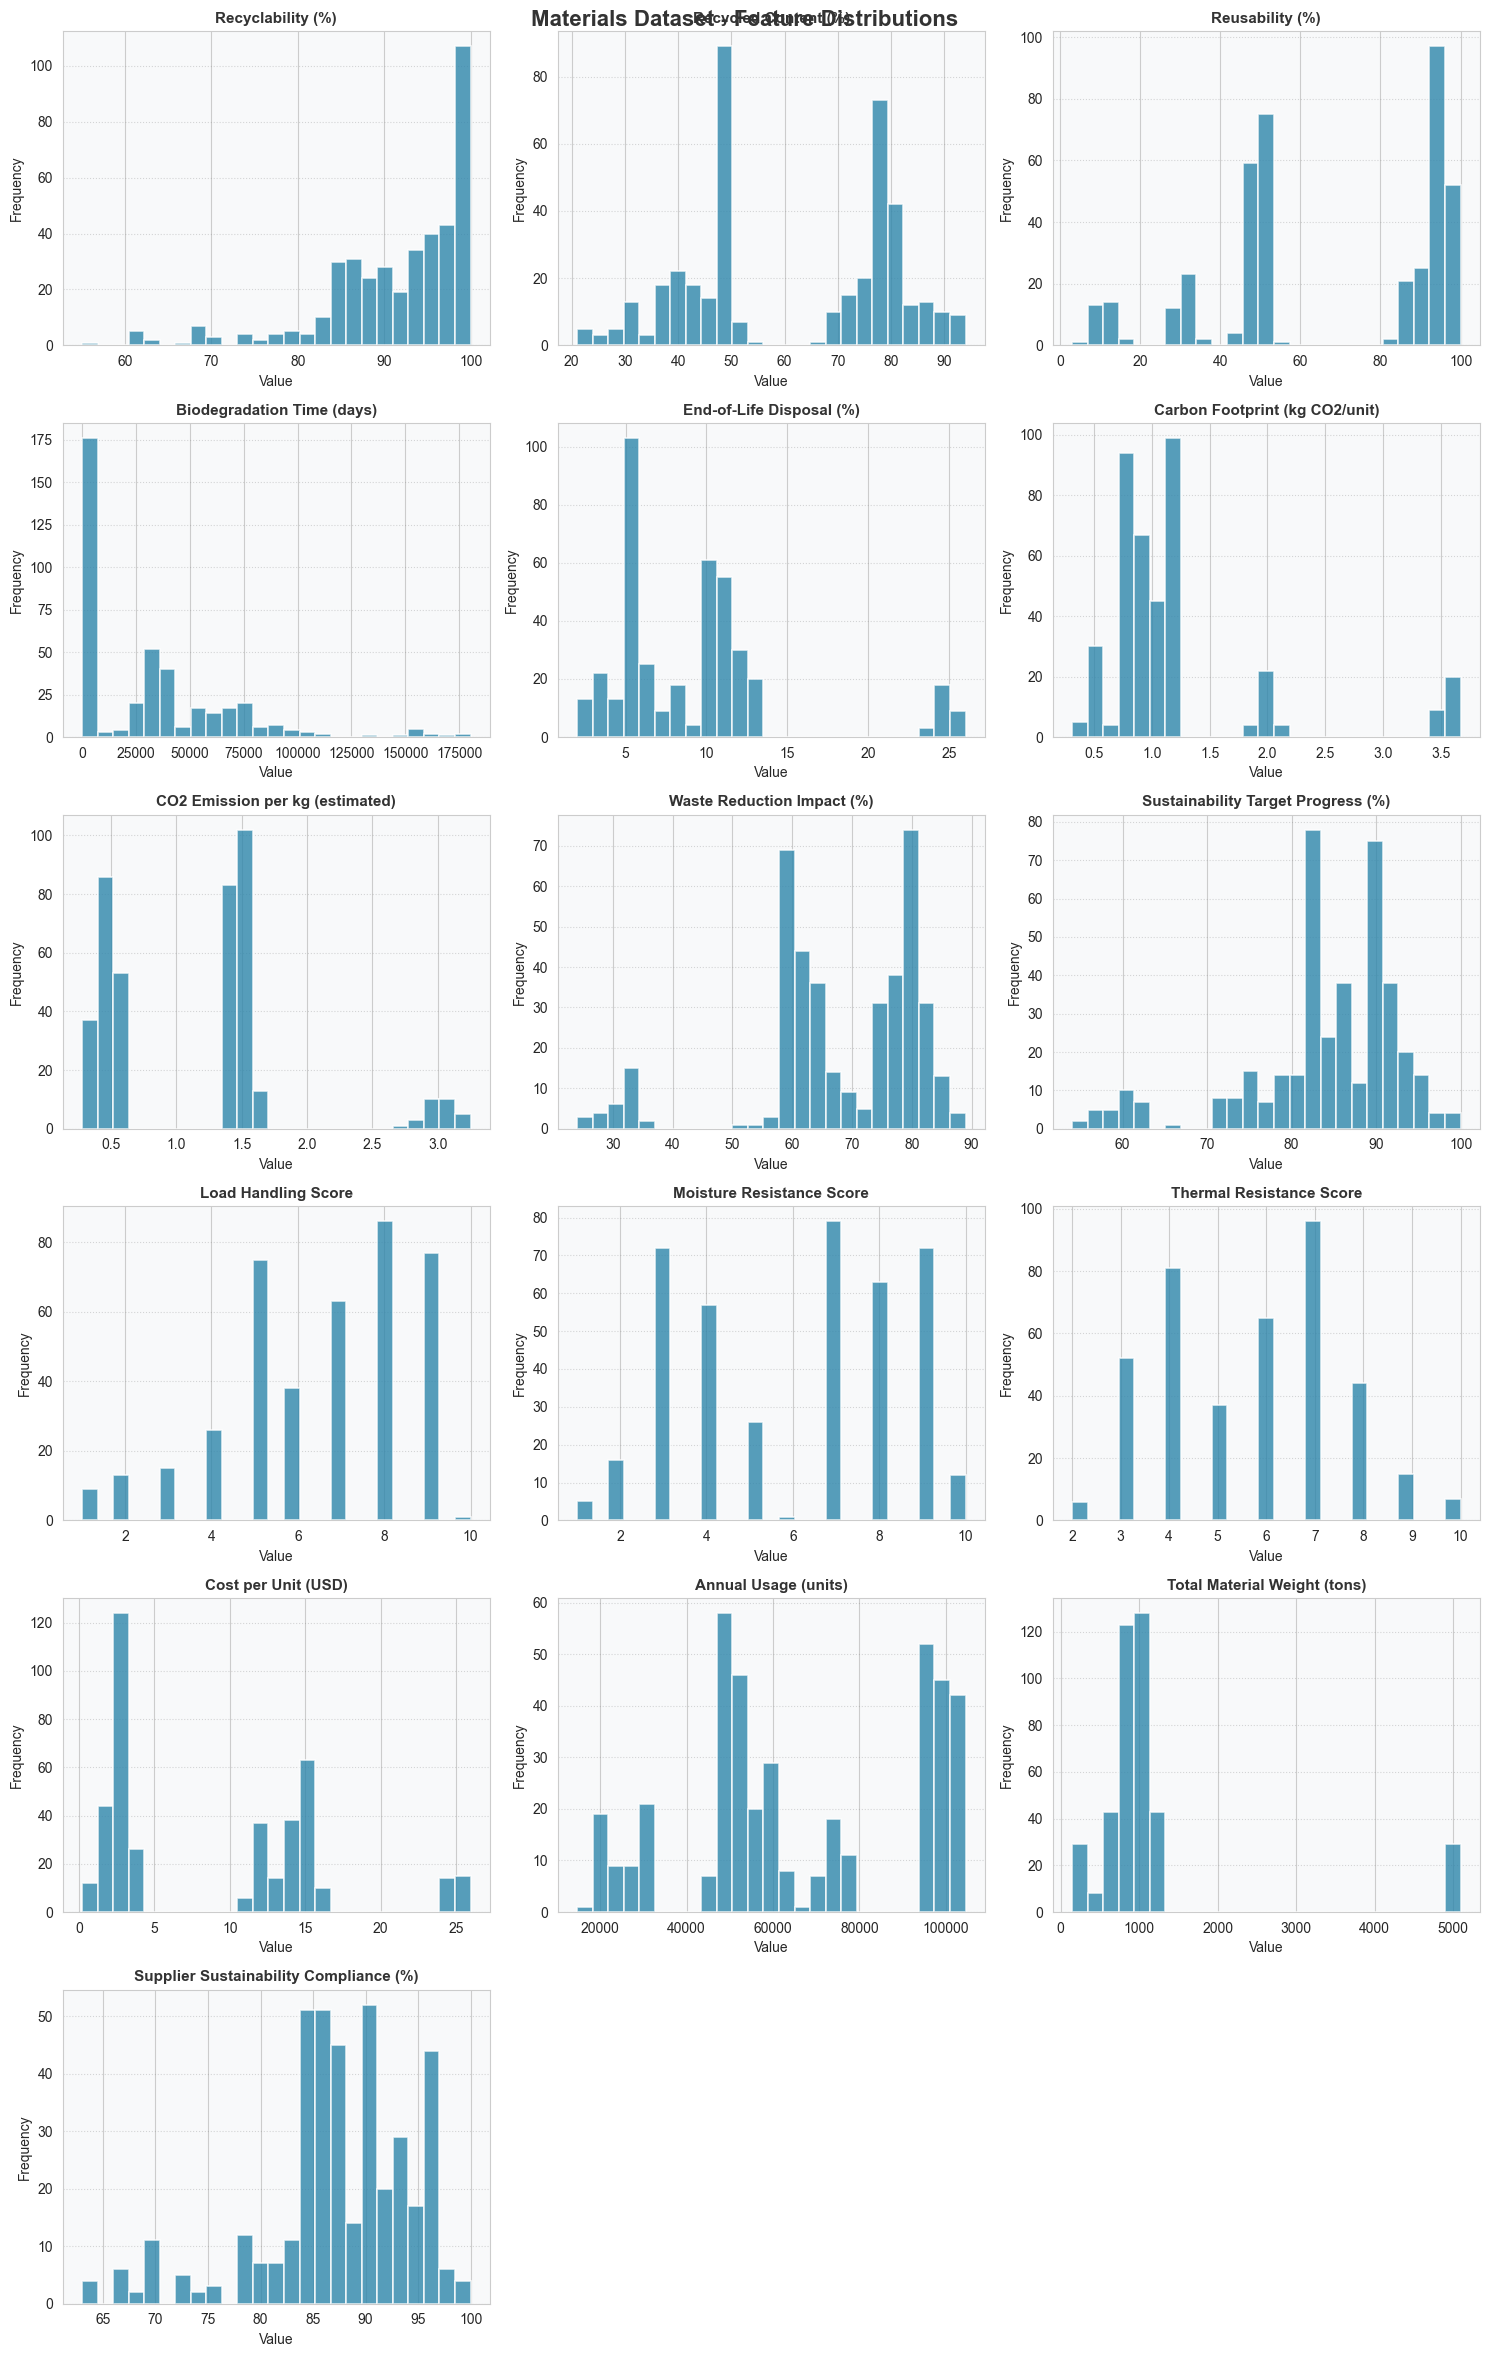

✓ Feature distribution plots saved successfully!
  Location: C:\Users\sneha\Desktop\AI-Powered-Sustainable-Packaging-Recommendation-System\data\eda_figures\material_feature_distributions.png


In [25]:
import matplotlib.pyplot as plt
import os

# Get numeric columns
numeric_cols = materials.select_dtypes(include=["int64", "float64"]).columns

# Calculate grid dimensions
n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3  # 3 columns per row

# Create figure
fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
axes = axes.flatten()

# Plot each feature
for idx, col in enumerate(numeric_cols):
    axes[idx].hist(materials[col], bins=25, 
                   color='#2E86AB', edgecolor='white', 
                   alpha=0.8, linewidth=1.2)
    axes[idx].set_title(col, fontsize=11, fontweight='bold', 
                       color='#333333')
    axes[idx].set_xlabel('Value', fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].set_facecolor('#F8F9FA')
    axes[idx].grid(axis='y', alpha=0.3, color='gray', linestyle=':')

# Hide extra subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

# Styling
fig.patch.set_facecolor('white')
plt.suptitle('Materials Dataset - Feature Distributions', 
             fontsize=16, fontweight='bold', color='#333333')
plt.tight_layout()

# Define and create save path
save_path = r"C:\Users\sneha\Desktop\AI-Powered-Sustainable-Packaging-Recommendation-System\data\eda_figures"
os.makedirs(save_path, exist_ok=True)

# Save figure
output_file = os.path.join(save_path, "material_feature_distributions.png")
plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight",
    facecolor='white'
)

plt.show()

print(f"Feature distribution plots saved successfully!")
print(f"  Location: {output_file}")

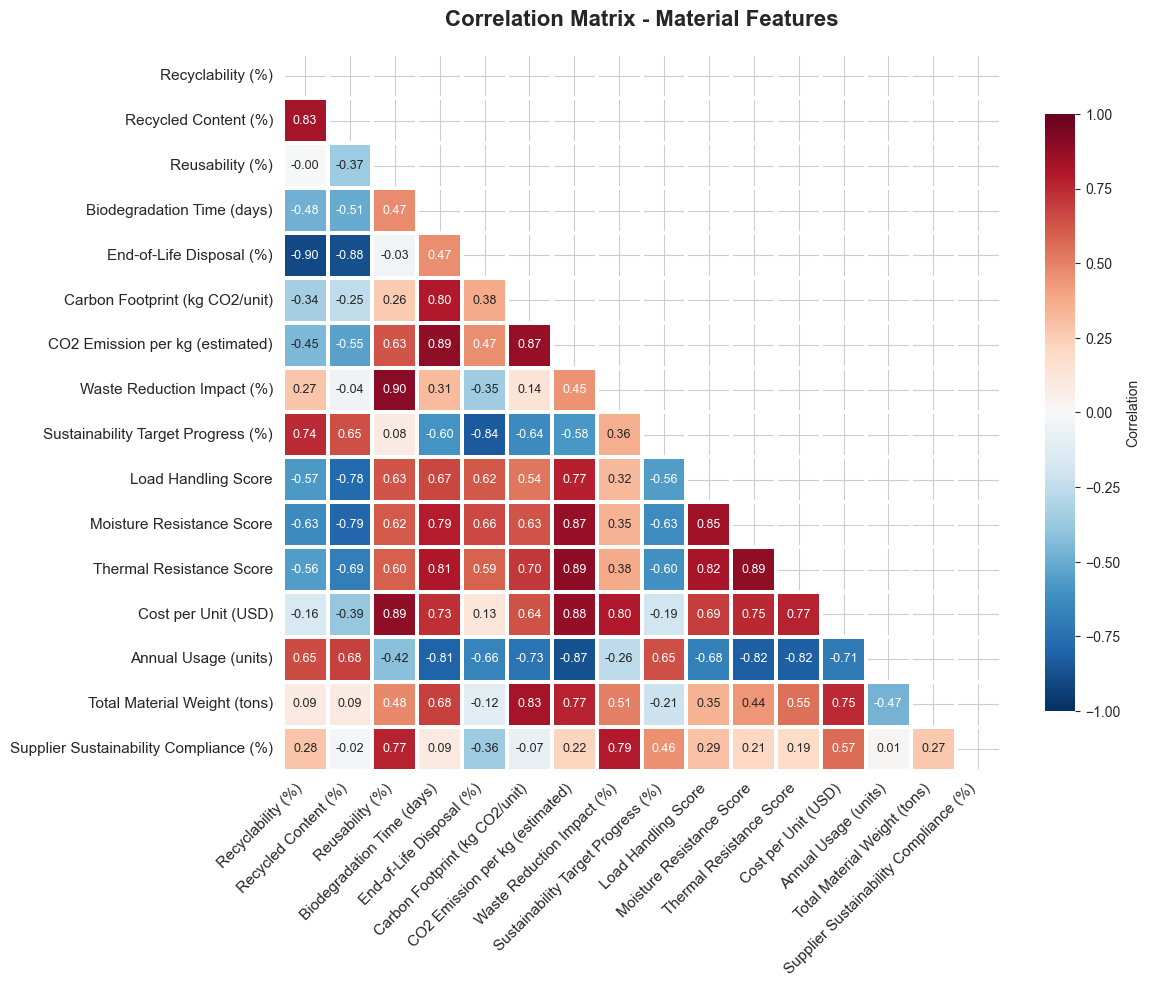

✓ Triangular correlation matrix saved successfully!
  Location: C:\Users\sneha\Desktop\AI-Powered-Sustainable-Packaging-Recommendation-System\data\eda_figures\material_correlation_matrix_triangular.png


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Calculate correlation matrix
corr_matrix = materials.select_dtypes(include=[np.number]).corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create figure
plt.figure(figsize=(12, 10))

# Create heatmap
sns.heatmap(corr_matrix, 
            mask=mask,            
            annot=True, 
            fmt='.2f',
            cmap='RdBu_r',       
            center=0,
            square=True,
            linewidths=1.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            vmin=-1, vmax=1,
            annot_kws={'size': 9})

plt.title('Correlation Matrix - Material Features', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

# Define and create save path
save_path = r"C:\Users\sneha\Desktop\AI-Powered-Sustainable-Packaging-Recommendation-System\data\eda_figures"
os.makedirs(save_path, exist_ok=True)

# Save figure
output_file = os.path.join(save_path, "material_correlation_matrix_triangular.png")
plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight",
    facecolor='white'
)

plt.show()

print(f"✓ Triangular correlation matrix saved successfully!")
print(f"  Location: {output_file}")

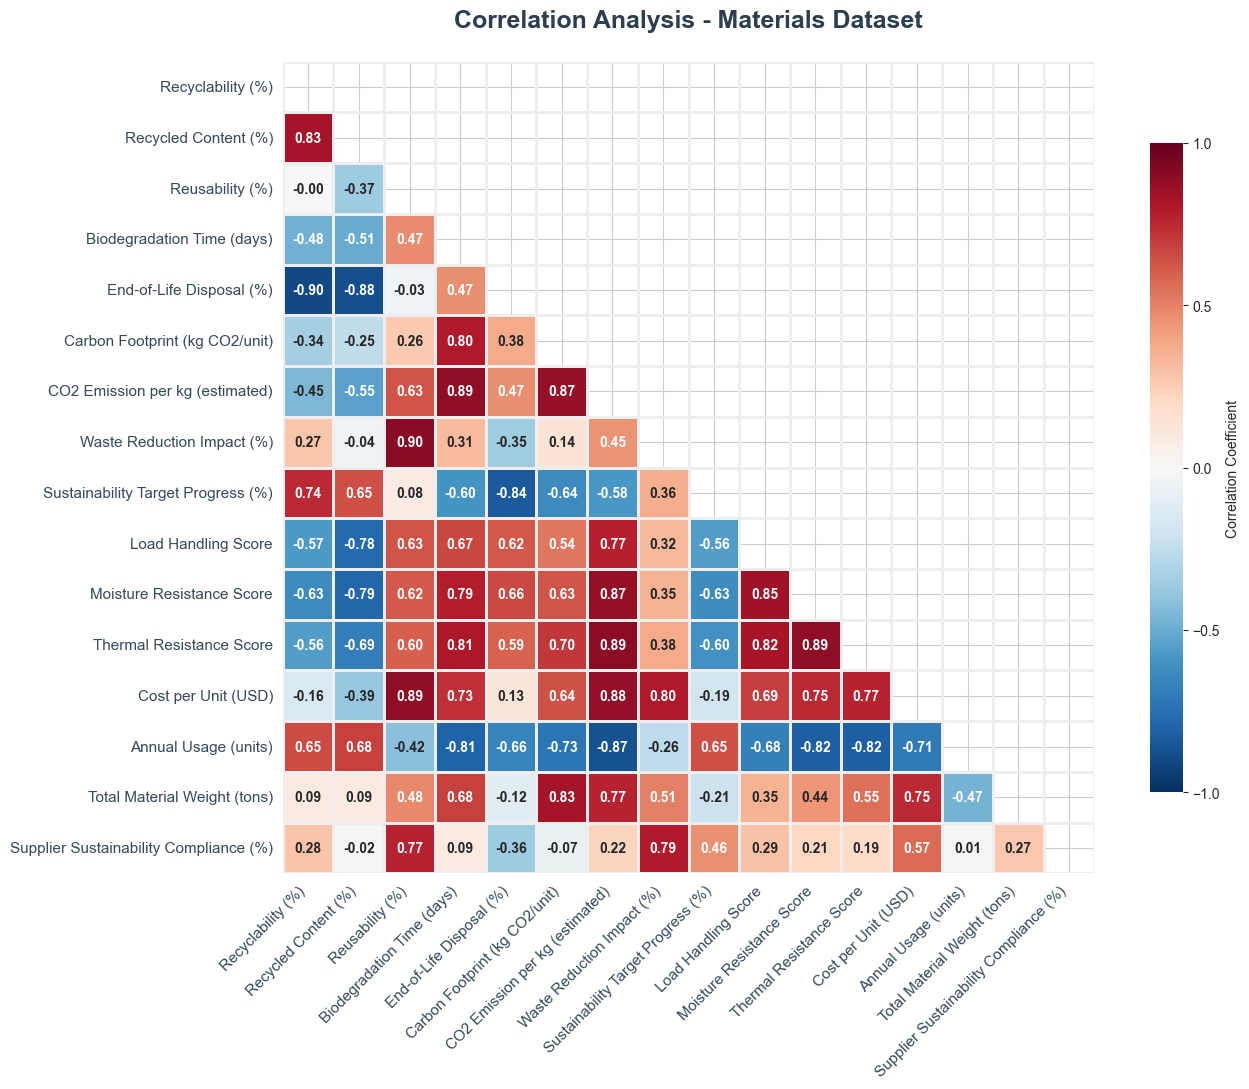

✓ Correlation heatmap saved successfully!
  Location: C:\Users\sneha\Desktop\AI-Powered-Sustainable-Packaging-Recommendation-System\data\eda_figures\material_correlation_heatmap.png


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Select numeric columns
materials_numeric = materials.select_dtypes(include=["int64", "float64"])

# Calculate correlation matrix
corr_matrix = materials_numeric.corr()

# Create mask for upper triangle (optional - removes redundancy)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create figure
plt.figure(figsize=(14, 11))

# Enhanced heatmap with professional styling
sns.heatmap(
    corr_matrix,
    mask=mask,              # Show only lower triangle
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",          # Red for negative, Blue for positive
    center=0,
    square=True,
    linewidths=2,
    linecolor='#EEEEEE',
    cbar_kws={
        'shrink': 0.8, 
        'label': 'Correlation Coefficient',
        'ticks': [-1, -0.5, 0, 0.5, 1]
    },
    vmin=-1, 
    vmax=1,
    annot_kws={'size': 10, 'weight': 'bold'}
)

# Enhanced styling
plt.title("Correlation Analysis - Materials Dataset", 
          fontsize=18, 
          fontweight='bold', 
          pad=25,
          color='#2C3E50')
plt.xticks(rotation=45, ha='right', fontsize=11, color='#34495E')
plt.yticks(rotation=0, fontsize=11, color='#34495E')

# Add border
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor('#BDC3C7')
    spine.set_linewidth(2)

plt.tight_layout()

# Define and create save path
save_path = r"C:\Users\sneha\Desktop\AI-Powered-Sustainable-Packaging-Recommendation-System\data\eda_figures"
os.makedirs(save_path, exist_ok=True)

# Save figure
output_file = os.path.join(save_path, "material_correlation_heatmap.png")
plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight",
    facecolor='white',
    edgecolor='none'
)

plt.show()

print(f"✓ Correlation heatmap saved successfully!")
print(f"  Location: {output_file}")

In [8]:
if "product_category" in products.columns:
    sns.countplot(data=products, x="product_category")
    plt.title("Product Category Distribution")
    plt.xticks(rotation=45)
    plt.show()


## Key EDA Insights

- Most material features follow a normal distribution
- Some features show correlation, indicating redundancy
- Product categories are unevenly distributed
- No extreme outliers were observed


## EDA Summary

The exploratory data analysis helped understand the structure,
distribution, and relationships in the datasets. These insights
guided preprocessing and feature engineering steps.
